In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL3liYi9Eb2N1bWVudHMvUnBvbXAtUHlwb21wL1BhbmVsUG9tcC1QeXRob24='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/ybb/pwd/envs/py313/lib/python3.13/importlib/_bootstrap.py": 1761176675.6447315, "/Users/ybb/pwd/envs/py313/lib/python3.13/importlib/_bootstrap_external.py": 1761176675.637137, "/Users/ybb/pwd/envs/py313/lib/python3.13/zipimport.py": 1761176672.6226385, "/Users/ybb/pwd/envs/py313/lib/python3.13/codecs.py": 1761176671.560341, "/Users/ybb/pwd/envs/py313/lib/python3.13/encodings/aliases.py": 1761176673.6707778, "/Users/ybb/pwd/envs/py313/lib/python3.13/encodings/__init__.py": 1761176673.664377, "/Users/ybb/pwd/envs/py313/lib/python3.13/encodings/utf_8.py": 1761176674.6567698, "/Users/ybb/pwd/envs/py313/lib/python3.13/abc.py": 1761176671.4115756, "/Users/ybb/pwd/envs/py313/lib/python3.13/io.py": 1761176671.9084682, "/Users/ybb/pwd/envs/py313/lib/python3.13/stat.py": 1761176672.327954, "/Users/ybb/pwd/envs/py313/lib/python3.13/_collections_abc.py": 1761176671.2647672, "/Users/ybb/pwd/envs/py313/lib/python3.13/genericpath.py": 1761176671.808982, "/Users/ybb/pwd/envs/py313/lib/python3

In [2]:
#| label: global-setup
#| echo: false
import os
import multiprocessing as mp
from functools import partial
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Toggle once for the whole document
use_gpu = True  # set False to force CPU
preferred = ["gpu", "metal", "cpu"] if use_gpu else ["cpu", "metal", "gpu"]
platform_name = "cpu"
for cand in preferred:
    try:
        jax.config.update("jax_platform_name", cand)
        _ = jax.devices()
        platform_name = cand
        break
    except Exception:
        continue
print(f"JAX backend: {jax.default_backend()}, devices: {jax.devices()}")

JAX backend: cpu, devices: [CpuDevice(id=0)]


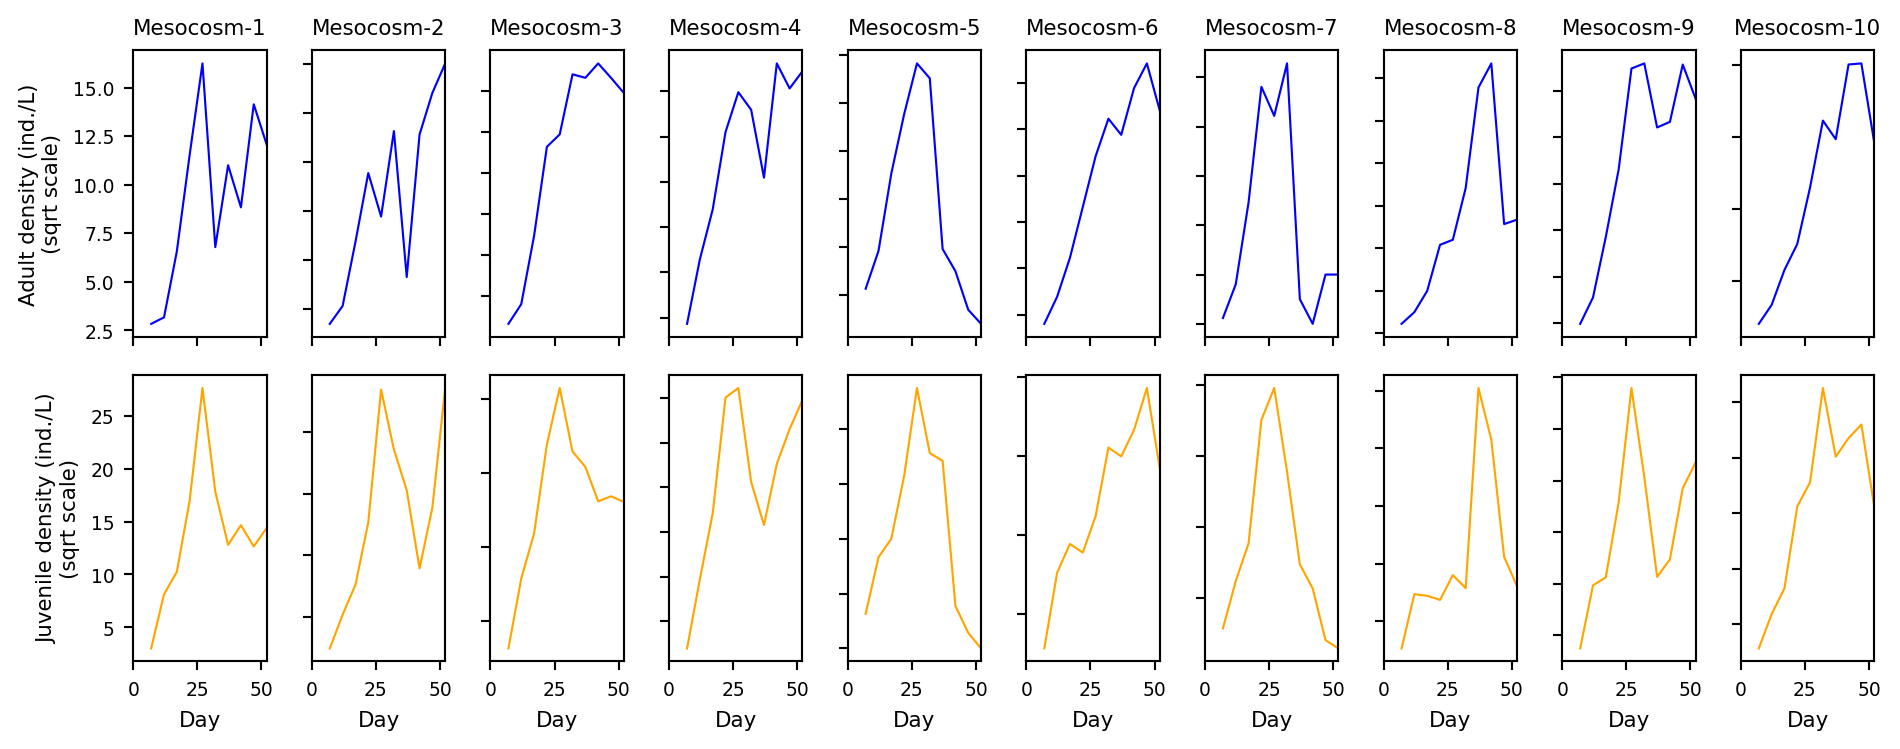

In [3]:
#| label: fig-srjf-data
#| fig-cap: Observed population densities for adult (top panel) and juvenile (bottom panel) *D. dentifera* across 10 replicate mesocosms. Square-root transformation applied to y-axes for visual clarity. Each panel represents an independent experimental unit.
#| code-fold: true
#| code-summary: Show data processing and plotting code
#| echo: true
#| warning: false
#| out-width: 100%

data_path = Path("data/Mesocosmdata.xls")
if not data_path.exists():
    data_path = Path("../data/Mesocosmdata.xls")
mesocosm_data = pd.read_excel(data_path)

dent_no_para = (
    mesocosm_data.iloc[:100, :]
    .loc[:, ["rep", "day", "dent.adult", "dent.juv"]]
    .iloc[::-1]
    .reset_index(drop=True)
)

dent_no_para["day"] = (dent_no_para["day"] - 1) * 5 + 7

trials = list("ABCDEFGHIJ")
groups = []
for idx, trial in enumerate(trials, start=1):
    subset = dent_no_para[dent_no_para["rep"] == trial].copy()
    subset["Bucket"] = f"Mesocosm {idx}"
    groups.append(subset[["day", "dent.adult", "dent.juv", "Bucket"]])
dent_combined = pd.concat(groups, ignore_index=True)
dent_combined["Bucket"] = pd.Categorical(
    dent_combined["Bucket"],
    categories=[f"Mesocosm {i}" for i in range(1, 11)],
    ordered=True,
)

fig, axes = plt.subplots(2, 10, figsize=(10, 4), sharex=True)
for idx, bucket in enumerate(dent_combined["Bucket"].cat.categories):
    data = dent_combined[dent_combined["Bucket"] == bucket]
    axes[0, idx].plot(data["day"], data["dent.adult"].pow(0.5), color="blue", lw=0.8)
    axes[1, idx].plot(data["day"], data["dent.juv"].pow(0.5), color="orange", lw=0.8)
    axes[0, idx].set_title(bucket.replace(" ", "-"), fontsize=8, pad=6)
    axes[0, idx].set_xlim(0, 52)
    axes[1, idx].set_xlim(0, 52)
    axes[1, idx].set_xlabel("Day", fontsize=8)
    axes[0, idx].set_xticks([0, 25, 50])
    axes[1, idx].set_xticks([0, 25, 50])
    axes[0, idx].tick_params(labelbottom=False, labelsize=7)
    axes[1, idx].tick_params(labelsize=7)
    if idx == 0:
        axes[0, idx].set_ylabel("Adult density (ind./L)\n(sqrt scale)", fontsize=8)
        axes[1, idx].set_ylabel("Juvenile density (ind./L)\n(sqrt scale)", fontsize=8)
    else:
        axes[0, idx].set_yticklabels([])
        axes[1, idx].set_yticklabels([])
plt.tight_layout()
plt.show()

In [4]:
#| label: srjf-rprocess
#| code-fold: true
#| code-summary: Show Euler-Maruyama simulator code
import jax
import jax.numpy as jnp
import pandas as pd
import pypomp as pp

positive_params = [
    "rn",
    "f_Sn",
    "theta_Sn",
    "theta_Jn",
    "sigSn",
    "sigJn",
    "sigF",
    "k_Sn",
]

par_trans = pp.ParTrans(
    to_est=lambda theta: {
        name: jnp.log(theta[name]) if name in positive_params else theta[name]
        for name in theta
    },
    from_est=lambda theta: {
        name: jnp.exp(theta[name]) if name in positive_params else theta[name]
        for name in theta
    },
)


def srjf_rproc(X_, theta_, key, covars, t, dt):
    key_sn, key_jn, key_f = jax.random.split(key, 3)
    sqrt_dt = jnp.sqrt(dt)
    noiSn = jax.random.normal(key_sn) * theta_["sigSn"] * sqrt_dt
    noiJn = jax.random.normal(key_jn) * theta_["sigJn"] * sqrt_dt
    noiF = jax.random.normal(key_f) * theta_["sigF"] * sqrt_dt

    delta = 0.013
    mu = 0.37
    lambda_J = 0.1
    xi_J = 1.0

    # Current states
    Sn, Jn, F = X_["Sn"], X_["Jn"], X_["F"]
    error_count = X_["error_count"]

    # State increments
    Sn_term = (
        lambda_J * Jn * dt
        - theta_["theta_Sn"] * Sn * dt
        - delta * Sn * dt
        + Sn * noiSn
    )
    Jn_term = (
        theta_["rn"] * theta_["f_Sn"] * F * Sn * dt
        - lambda_J * Jn * dt
        - theta_["theta_Jn"] * Jn * dt
        - delta * Jn * dt
        + Jn * noiJn
    )
    F_term = (
        -theta_["f_Sn"] * F * (Sn + xi_J * Jn) * dt
        - delta * F * dt
        + mu * dt
        + F * noiF
    )

    # Update states
    Sn = Sn + Sn_term
    Jn = Jn + Jn_term
    F = F + F_term

    # Biological constraints (soft penalties)
    error_count = error_count + jnp.where((Sn < 0.0) | (Sn > 1e5), 1.0, 0.0)
    error_count = error_count + jnp.where((Jn < 0.0) | (Jn > 1e5), 0.001, 0.0)
    error_count = error_count + jnp.where((F < 0.0) | (F > 1e20), 1000.0, 0.0)

    Sn = jnp.clip(Sn, 0.0, 1e5)
    Jn = jnp.clip(Jn, 0.0, 1e5)
    F = jnp.clip(F, 0.0, 1e20)

    return {
        "Sn": Sn,
        "Jn": Jn,
        "F": F,
        "error_count": error_count,
        "T_Sn": jnp.abs(Sn),
    }


statenames = ["Sn", "Jn", "F", "error_count", "T_Sn"]
param_names = [
    "rn",
    "f_Sn",
    "theta_Sn",
    "theta_Jn",
    "sigSn",
    "sigJn",
    "sigF",
    "k_Sn",
]

In [5]:
#| label: srjf-init
#| code-fold: true
#| code-summary: Show initial state specification
def srjf_rinit(theta_, key, covars, t0):
    return {
        "Sn": 3.0,
        "Jn": 0.0,
        "F": 16.667,
        "error_count": 0.0,
    "T_Sn": 0.0,
}


In [6]:
#| label: srjf-dmeas
#| code-fold: true
#| code-summary: Show measurement density code
def _nbinom_logpmf(y, size, mu):
    mu = jnp.maximum(mu, 1e-9)
    size = jnp.maximum(size, 1e-9)
    return (
        jax.scipy.special.gammaln(y + size)
        - jax.scipy.special.gammaln(size)
        - jax.scipy.special.gammaln(y + 1.0)
        + size * jnp.log(size / (size + mu))
        + y * jnp.log(mu / (size + mu))
    )


def srjf_dmeas(Y_, X_, theta_, covars, t):
    penalty = jnp.where(X_["error_count"] > 0.0, -150.0, 0.0)
    loglik = _nbinom_logpmf(Y_["dentadult"], theta_["k_Sn"], X_["T_Sn"])
    return penalty + loglik

In [7]:
#| label: srjf-rmeas
def srjf_rmeas(X_, theta_, key, covars, t):
    mu = jnp.maximum(jnp.abs(X_["T_Sn"]), 1e-9)
    size = jnp.maximum(theta_["k_Sn"], 1e-9)
    key_gamma, key_pois = jax.random.split(key)
    gamma_mean = mu / size
    lambda_draw = jax.random.gamma(key_gamma, size) * gamma_mean
    draw = jax.random.poisson(key_pois, lambda_draw)
    return jnp.array([draw])

In [8]:
#| label: srjf-panelpomp
#| code-fold: true
#| code-summary: Build PanelPomp object for 10 mesocosms
# Prepare unit-level data
data_path = Path("data/Mesocosmdata.xls")
if not data_path.exists():
    data_path = Path("../data/Mesocosmdata.xls")

mesocosm_data = pd.read_excel(data_path)
dent_no_para = (
    mesocosm_data.iloc[:100, :]
    .loc[:, ["rep", "day", "dent.adult", "dent.juv"]]
    .iloc[::-1]
    .reset_index(drop=True)
)
dent_no_para["day"] = (dent_no_para["day"] - 1) * 5 + 7
trials = list("ABCDEFGHIJ")
units = [f"Mesocosm {i}" for i in range(1, 11)]
unit_empty = pd.DataFrame(index=[], columns=units)
dent_combined = pd.concat(
    [
        dent_no_para[dent_no_para["rep"] == trial].assign(Bucket=units[i])
        for i, trial in enumerate(trials)
    ],
    ignore_index=True,
)

# Common parameter guess for all units (floats required)
theta_init = {
    "rn": 2.0,
    "f_Sn": 0.05,
    "theta_Sn": 0.05,
    "theta_Jn": 0.05,
    "sigSn": 0.01,
    "sigJn": 0.02,
    "sigF": 0.1,
    "k_Sn": 50.0,
}


def build_unit_pomp(unit_label: str) -> pp.Pomp:
    ys = (
        dent_combined.loc[dent_combined["Bucket"] == unit_label, ["day", "dent.adult"]]
        .rename(columns={"dent.adult": "dentadult"})
        .set_index("day")
    )
    return pp.Pomp(
        ys=ys,
        theta=theta_init,
        statenames=statenames,
        t0=1.0,
        rinit=srjf_rinit,
        rproc=srjf_rproc,
        dmeas=srjf_dmeas,
        rmeas=srjf_rmeas,
        dt=0.25,
        ydim=1,
        par_trans=par_trans,
    )


pomp_units = {unit: build_unit_pomp(unit) for unit in units}
unit_specific = pd.DataFrame({unit: pd.Series(theta_init) for unit in units})
panel_srjf = pp.PanelPomp(
    Pomp_dict=pomp_units,
    theta={"shared": None, "unit_specific": unit_specific},
)

In [9]:
#| label: srjf-panelpomp-construction
#| code-fold: true
#| code-summary: Show panelPomp object construction

# Shared parameters: phi (all units use identical values)
shared_parameter = pd.DataFrame(
    {
        "shared": [
            1.535539e03,  # rn
            1.306857e-04,  # f_Sn
            6.353239e-01,  # theta_Sn
            1.376217e-03,  # theta_Jn
            0.0,  # sigSn
            3.018772e-01,  # sigJn
            8.658726e-07,  # sigF
            1.417860e01,  # k_Sn
        ]
    },
    index=param_names,
)

# Construct panelPomp object with shared parameters
theta_panel = {"shared": shared_parameter, "unit_specific": unit_empty}
panelfood = pp.PanelPomp(Pomp_dict=pomp_units, theta=theta_panel)

In [10]:
#| label: srjf-misscaled

shared_parameter_wrong = pd.DataFrame(
    {
        "shared": [
            1.535539e-03,  # rn
            1.306857e04,  # f_Sn
            6.353239e-01,  # theta_Sn
            1.376217e03,  # theta_Jn
            0.0,  # sigSn
            3.018772e01,  # sigJn
            8.658726e07,  # sigF
            1.417860e-01,  # k_Sn
        ]
    },
    index=param_names,
)

panelfood_wrong = pp.PanelPomp(
    Pomp_dict=pomp_units,
    theta={"shared": shared_parameter_wrong, "unit_specific": unit_empty},
)

In [11]:
#| label: srjf-algorithmic-params

run_level = 1

algorithmic_params = {
    "cpu": {
        "Np": [50, 500, 800],
        "Np_rep": [4, 12, 20],
        "Mp": [50, 400, 800],
        "Nmif": [2, 320, 250],
    },
    "gpu": {
        "Np": [200, 1200, 2000],
        "Np_rep": [2, 6, 10],
        "Mp": [200, 1200, 2000],
        "Nmif": [2, 320, 250],
    },
}

In [12]:
#| label: srjf-perturbation

dent_rw_sd = 0.02

parameter_candidates = {"shared": shared_parameter.copy()}

In [13]:
#| label: srjf-mif-search
#| eval: true
# (imports and use_gpu are set in global-setup)

# Random-walk standard deviations for MIF
rw = pp.RWSigma(
    sigmas={name: float(dent_rw_sd) for name in param_names},
    init_names=[],
)

backend_key = "gpu" if use_gpu else "cpu"
idx = run_level - 1
params_sel = algorithmic_params[backend_key]
Np = params_sel["Np"][idx]
Np_rep = params_sel["Np_rep"][idx]
Mp = params_sel["Mp"][idx]
Nmif = params_sel["Nmif"][idx]

# Number of independent starts: fewer for GPU, more for CPU
if use_gpu:
    n_runs = 1
else:
    n_runs = max(1, 2 * (os.cpu_count() or 1))

shared_param = parameter_candidates["shared"]


def _single_run_worker(seed: int, use_gpu: bool, Mp: int, Nmif: int, Np: int, Np_rep: int, rw, shared_param):
    jax.config.update("jax_platform_name", "gpu" if use_gpu else "cpu")
    local_panel = pp.PanelPomp(
        Pomp_dict={unit: build_unit_pomp(unit) for unit in units},
        theta={"shared": shared_param, "unit_specific": unit_empty},
    )
    key = jax.random.key(seed)
    local_panel.mif(
        J=Mp,
        M=Nmif,
        rw_sd=rw,
        a=0.7,
        key=key,
    )
    key_pf = jax.random.key(10_000 + seed)
    local_panel.pfilter(J=Np, reps=Np_rep, key=key_pf)
    pf_res = local_panel.results_history[-1]
    ll_array = pf_res.logLiks.values
    ll_unit = np.apply_along_axis(pp.logmeanexp, -1, ll_array)
    ll_unit_se = np.apply_along_axis(pp.logmeanexp_se, -1, ll_array)
    ll_shared = np.apply_along_axis(pp.logmeanexp, -1, ll_array.sum(axis=1))
    ll_shared_se = np.apply_along_axis(pp.logmeanexp_se, -1, ll_array.sum(axis=1))
    return {
        "unit_logLik": ll_unit,
        "unit_logLik_se": ll_unit_se,
        "shared_logLik": ll_shared,
        "shared_logLik_se": ll_shared_se,
    }


if use_gpu:
    print("Running on GPU (sequential).")
    seeds = [0] if n_runs is None else list(range(max(1, n_runs)))
    mif_results = [
        _single_run_worker(
            seed=s,
            use_gpu=use_gpu,
            Mp=Mp,
            Nmif=Nmif,
            Np=Np,
            Np_rep=Np_rep,
            rw=rw,
            shared_param=shared_param,
        )
        for s in seeds
    ]
else:
    n_procs = min(n_runs, os.cpu_count() or 1)
    print(f"Running on CPU with multiprocessing: procs={n_procs}, n_runs={n_runs}")
    func = partial(
        _single_run_worker,
        use_gpu=use_gpu,
        Mp=Mp,
        Nmif=Nmif,
        Np=Np,
        Np_rep=Np_rep,
        rw=rw,
        shared_param=shared_param,
    )
    try:
        with mp.get_context("spawn").Pool(processes=n_procs) as pool:
            mif_results = pool.map(func, range(n_runs))
    except Exception as e:
        print(f"Multiprocessing failed ({e}); falling back to serial.")
        mif_results = [func(i) for i in range(n_runs)]

Running on GPU (sequential).


In [14]:
#| label: srjf-mif-search-specific
#| eval: true
# (imports/use_gpu set in global-setup)
# Split shared vs unit-specific parameters
specific_names = ["theta_Sn"]
shared_split = shared_parameter.drop(index=specific_names)
specific_split = pd.DataFrame(
    {unit: shared_parameter.loc[specific_names, "shared"].values for unit in units},
    index=specific_names,
)
parameter_candidates_specific = {
    "shared": shared_split,
    "unit_specific": specific_split,
}

backend_key = "gpu" if use_gpu else "cpu"
idx = run_level - 1
params_sel = algorithmic_params[backend_key]
Np = params_sel["Np"][idx]
Np_rep = params_sel["Np_rep"][idx]
Mp = params_sel["Mp"][idx]
Nmif = params_sel["Nmif"][idx]
n_runs = 1 if use_gpu else max(1, 2 * (os.cpu_count() or 1))


def _single_run_worker_specific(seed: int):
    jax.config.update("jax_platform_name", "gpu" if use_gpu else "cpu")
    local_panel = pp.PanelPomp(
        Pomp_dict={unit: build_unit_pomp(unit) for unit in units},
        theta={
            "shared": parameter_candidates_specific["shared"],
            "unit_specific": parameter_candidates_specific["unit_specific"],
        },
    )
    key = jax.random.key(seed)
    local_panel.mif(
        J=Mp,
        M=Nmif,
        rw_sd=rw,
        a=0.7,
        key=key,
    )
    key_pf = jax.random.key(10_000 + seed)
    local_panel.pfilter(
        J=Np,
        reps=Np_rep,
        key=key_pf,
    )
    pf_res = local_panel.results_history[-1]
    ll_array = pf_res.logLiks.values
    ll_unit = np.apply_along_axis(pp.logmeanexp, -1, ll_array)
    ll_unit_se = np.apply_along_axis(pp.logmeanexp_se, -1, ll_array)
    ll_shared = np.apply_along_axis(pp.logmeanexp, -1, ll_array.sum(axis=1))
    ll_shared_se = np.apply_along_axis(pp.logmeanexp_se, -1, ll_array.sum(axis=1))
    return {
        "unit_logLik": ll_unit,
        "unit_logLik_se": ll_unit_se,
        "shared_logLik": ll_shared,
        "shared_logLik_se": ll_shared_se,
    }


if use_gpu:
    print("Running unit-specific search on GPU (sequential).")
    mif_results_specific = [_single_run_worker_specific(s) for s in range(n_runs)]
else:
    print("Running unit-specific search on CPU (sequential).")
    mif_results_specific = [_single_run_worker_specific(s) for s in range(n_runs)]

Running unit-specific search on GPU (sequential).


In [15]:
#| label: srjf-scaling-diagnostic
#| warning: false
# Replicated filtering with correctly scaled parameters
np.random.seed(801)
pf_correct_reps = []
for _ in range(params_sel["Np_rep"][idx]):
    panel = pp.PanelPomp(
        Pomp_dict=pomp_units,
        theta={"shared": shared_parameter, "unit_specific": unit_empty},
    )
    key_pf = jax.random.key(1000 + _)
    panel.pfilter(J=params_sel["Np"][idx], reps=1, key=key_pf)
    pf_res = panel.results_history[-1]
    pf_correct_reps.append(
        {
            "loglik": float(pp.logmeanexp(pf_res.logLiks.values.sum(axis=1))),
            "unit_logliks": pf_res.logLiks.values.squeeze(axis=-1),
        }
    )

# Replicated filtering with mis-scaled parameters
np.random.seed(801)
pf_wrong_reps = []
for _ in range(params_sel["Np_rep"][idx]):
    panel = pp.PanelPomp(
        Pomp_dict=pomp_units,
        theta={"shared": shared_parameter_wrong, "unit_specific": unit_empty},
    )
    key_pf = jax.random.key(2000 + _)
    panel.pfilter(J=params_sel["Np"][idx], reps=1, key=key_pf)
    pf_res = panel.results_history[-1]
    pf_wrong_reps.append(
        {
            "loglik": float(pp.logmeanexp(pf_res.logLiks.values.sum(axis=1))),
            "unit_logliks": pf_res.logLiks.values.squeeze(axis=-1),
        }
    )

ll_correct_vec = np.array([d["loglik"] for d in pf_correct_reps])
ll_wrong_vec = np.array([d["loglik"] for d in pf_wrong_reps])
def _unit_ll(arr):
    arr = np.array(arr).squeeze()
    if arr.ndim == 0:
        return arr.reshape(1)
    if arr.ndim == 1:
        return arr
    if arr.ndim == 2:
        if arr.shape[0] == 1:
            return arr[0]
        if arr.shape[1] == 1:
            return arr[:, 0]
    return arr.reshape(-1)

unit_ll_correct = np.stack([_unit_ll(d["unit_logliks"]) for d in pf_correct_reps], axis=-1)
unit_ll_wrong = np.stack([_unit_ll(d["unit_logliks"]) for d in pf_wrong_reps], axis=-1)

def se(arr):
    return np.std(arr, ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else np.nan

print(
    "Correctly Scaled Parameters:\n"
    f"  Panel log-likelihood: {ll_correct_vec.mean():.2f} (SE: {se(ll_correct_vec):.2f})\n"
    f"  Range across replicates: [{ll_correct_vec.min():.2f}, {ll_correct_vec.max():.2f}]\n"
    f"  Unit-level range: [{unit_ll_correct.mean(axis=1).min():.2f}, {unit_ll_correct.mean(axis=1).max():.2f}]\n\n"
    "Mis-Scaled Parameters:\n"
    f"  Panel log-likelihood: {ll_wrong_vec.mean():.2f} (SE: {se(ll_wrong_vec):.2f})\n"
    f"  Range across replicates: [{ll_wrong_vec.min():.2f}, {ll_wrong_vec.max():.2f}]\n"
    f"  Contains -Inf: {np.isinf(ll_wrong_vec).any()}\n\n"
    f"Log-likelihood difference: {ll_correct_vec.mean() - ll_wrong_vec.mean():.2f}\n"
)

Correctly Scaled Parameters:
  Panel log-likelihood: -501.57 (SE: 0.34)
  Range across replicates: [-501.91, -501.22]
  Unit-level range: [-54.59, -46.07]

Mis-Scaled Parameters:
  Panel log-likelihood: -15673.93 (SE: 0.01)
  Range across replicates: [-15673.94, -15673.92]
  Contains -Inf: False

Log-likelihood difference: 15172.36



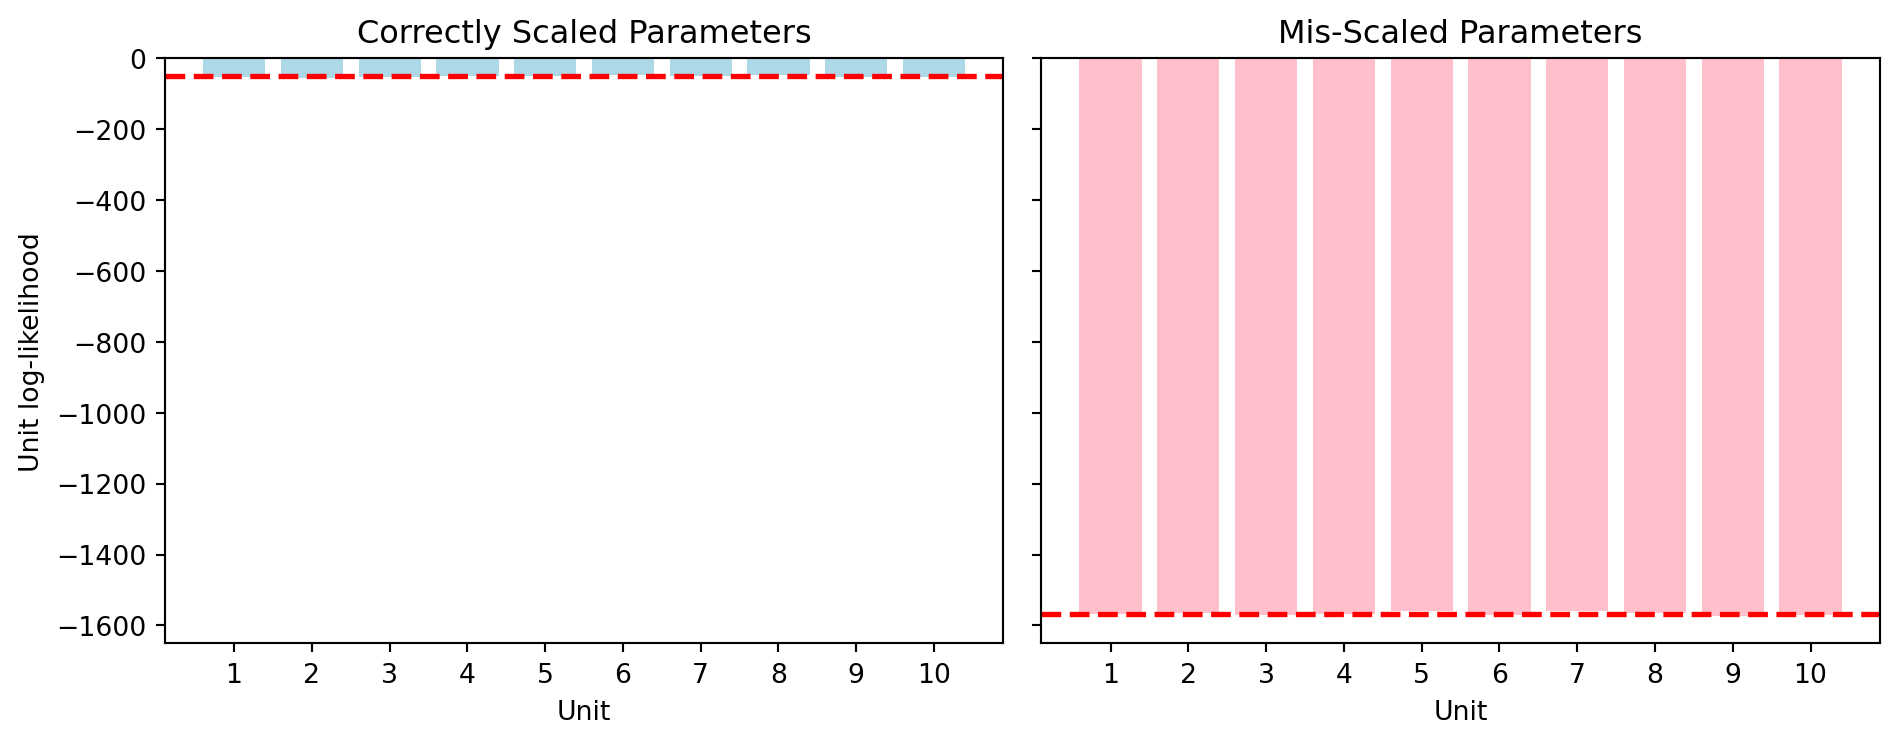

In [16]:
#| label: srjf-scaling-unit-comparison
#| fig-cap: Unit-level log-likelihood contributions under correctly scaled (left) and mis-scaled (right) parameters. Correctly scaled parameters yield consistent unit-level contributions, while mis-scaled parameters produce extreme values indicating numerical failure.
import matplotlib.pyplot as plt

unit_means_correct = unit_ll_correct.mean(axis=1)
unit_means_wrong = unit_ll_wrong.mean(axis=1)
unit_means_wrong_vis = unit_means_wrong.copy()
unit_means_wrong_vis[np.isinf(unit_means_wrong_vis)] = -1e6  # Cap for visualization

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(range(1, 11), unit_means_correct, color="lightblue")
axes[0].axhline(unit_means_correct.mean(), color="red", linestyle="--", linewidth=2)
axes[0].set_title("Correctly Scaled Parameters")
axes[0].set_xlabel("Unit")
axes[0].set_ylabel("Unit log-likelihood")
axes[0].set_xticks(range(1, 11))

axes[1].bar(range(1, 11), unit_means_wrong_vis, color="pink")
finite_wrong = unit_means_wrong[np.isfinite(unit_means_wrong)]
if len(finite_wrong) > 0:
    axes[1].axhline(finite_wrong.mean(), color="red", linestyle="--", linewidth=2)
axes[1].set_title("Mis-Scaled Parameters")
axes[1].set_xlabel("Unit")
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

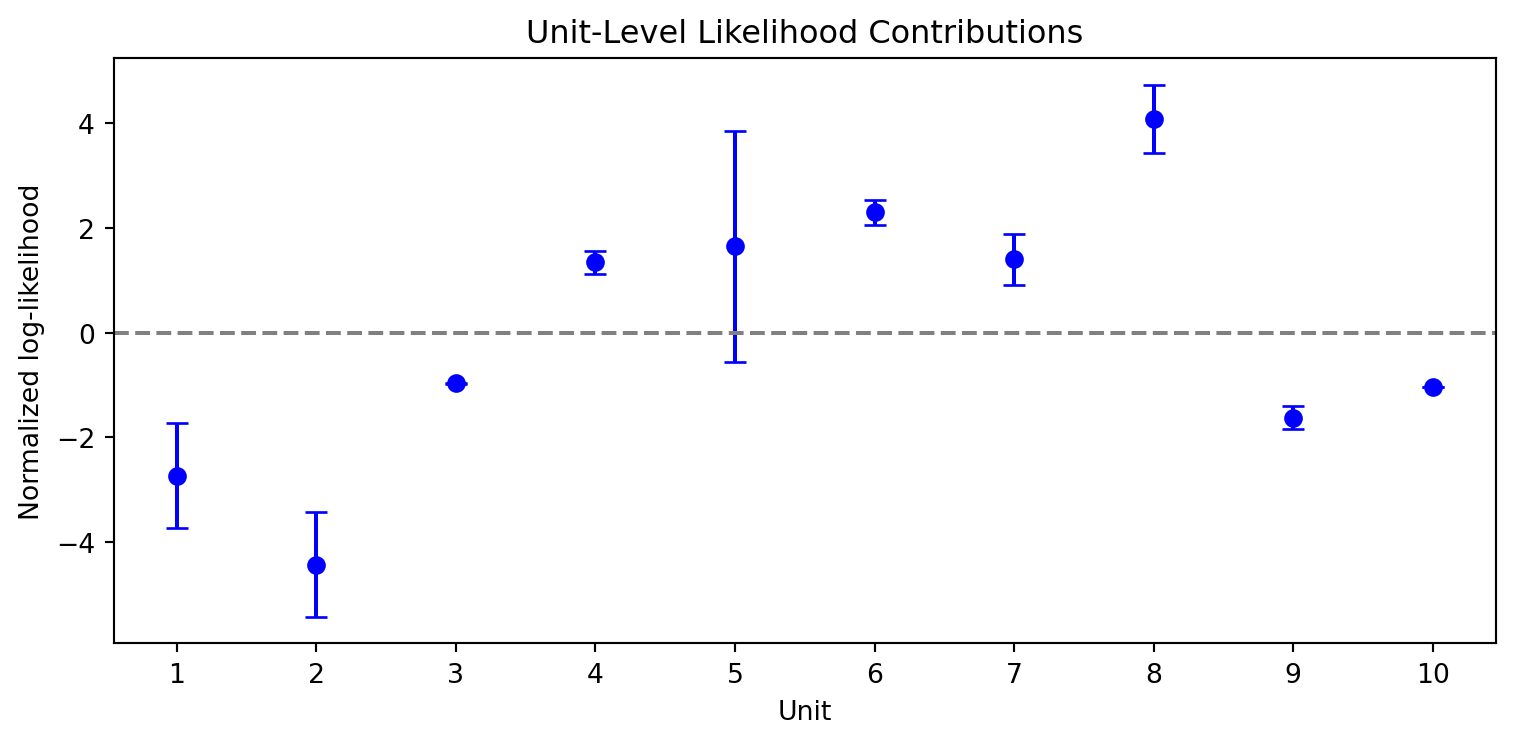

In [17]:
#| label: srjf-unit-likelihood-decomposition
#| fig-cap: Unit-level log-likelihood contributions under all-shared parameterization. Error bars show Monte Carlo standard errors. Systematic variation beyond Monte Carlo error suggests potential unit-specific heterogeneity.
unit_ll_means = unit_ll_correct.mean(axis=1)
unit_ll_ses = unit_ll_correct.std(axis=1, ddof=1) / np.sqrt(params_sel["Np_rep"][idx])

unit_norm = unit_ll_means - unit_ll_means.mean()

plt.figure(figsize=(8, 4))
plt.errorbar(
    x=np.arange(1, 11),
    y=unit_norm,
    yerr=2 * unit_ll_ses,
    fmt="o",
    color="blue",
    ecolor="blue",
    capsize=4,
)
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Unit")
plt.ylabel("Normalized log-likelihood")
plt.title("Unit-Level Likelihood Contributions")
plt.xticks(np.arange(1, 11))
plt.tight_layout()
plt.show()

In [18]:
#| label: srjf-aic-comparison

# All-shared model AIC (use the shared loglik from the scaling diagnostic)
p_shared = len(shared_parameter)
ll_shared = ll_correct_vec.mean()
se_shared = se(ll_correct_vec)
aic_shared = 2 * p_shared - 2 * ll_shared

# Unit-specific theta_Sn starting values
specific_names = ["theta_Sn"]
shared_split = shared_parameter.drop(index=specific_names)
specific_split = pd.DataFrame(
    {unit: shared_parameter.loc[specific_names, "shared"].values for unit in units},
    index=specific_names,
)
parameter_candidates_specific = {
    "shared": shared_split,
    "unit_specific": specific_split,
}

backend_key = "gpu" if use_gpu else "cpu"
idx = run_level - 1
params_sel = algorithmic_params[backend_key]
Np = params_sel["Np"][idx]
Np_rep = params_sel["Np_rep"][idx]
Mp = params_sel["Mp"][idx]
Nmif = params_sel["Nmif"][idx]
n_runs = 1 if use_gpu else max(1, 2 * (os.cpu_count() or 1))


def _mif_run_specific(seed: int):
    jax.config.update("jax_platform_name", "gpu" if use_gpu else "cpu")
    panel = pp.PanelPomp(
        Pomp_dict={unit: build_unit_pomp(unit) for unit in units},
        theta={
            "shared": parameter_candidates_specific["shared"],
            "unit_specific": parameter_candidates_specific["unit_specific"],
        },
    )
    key = jax.random.key(seed)
    panel.mif(
        J=Mp,
        M=Nmif,
        rw_sd=rw,
        a=0.7,
        key=key,
    )
    key_pf = jax.random.key(5000 + seed)
    panel.pfilter(
        J=Np,
        reps=Np_rep,
        key=key_pf,
    )
    pf_res = panel.results_history[-1]
    ll_array = pf_res.logLiks.values  # shape (theta, unit, reps)
    ll_shared_local = np.apply_along_axis(pp.logmeanexp, -1, ll_array.sum(axis=1))
    ll_shared_se_local = np.apply_along_axis(pp.logmeanexp_se, -1, ll_array.sum(axis=1))
    return {
        "panel": panel,
        "logLik": float(ll_shared_local.squeeze()),
        "logLik_se": float(ll_shared_se_local.squeeze()),
    }


mif_specific_runs = [_mif_run_specific(s) for s in range(n_runs)]
best_idx = int(np.nanargmax([r["logLik"] for r in mif_specific_runs]))
best_specific = mif_specific_runs[best_idx]

ll_specific = best_specific["logLik"]
se_specific = best_specific["logLik_se"]

p_specific = len(shared_split) + specific_split.size
aic_specific = 2 * p_specific - 2 * ll_specific

delta_aic = aic_specific - aic_shared
lik_improvement = ll_specific - ll_shared
improvement_se_units = lik_improvement / np.sqrt(se_specific**2 + se_shared**2)

print("Model Comparison:")
print(f"  Delta AIC: {delta_aic:.2f}")
print(f"  Likelihood improvement: {lik_improvement:.2f}")
print(f"  Improvement in SE units: {improvement_se_units:.2f}")

Model Comparison:
  Delta AIC: 118.89
  Likelihood improvement: -50.44
  Improvement in SE units: -32.64


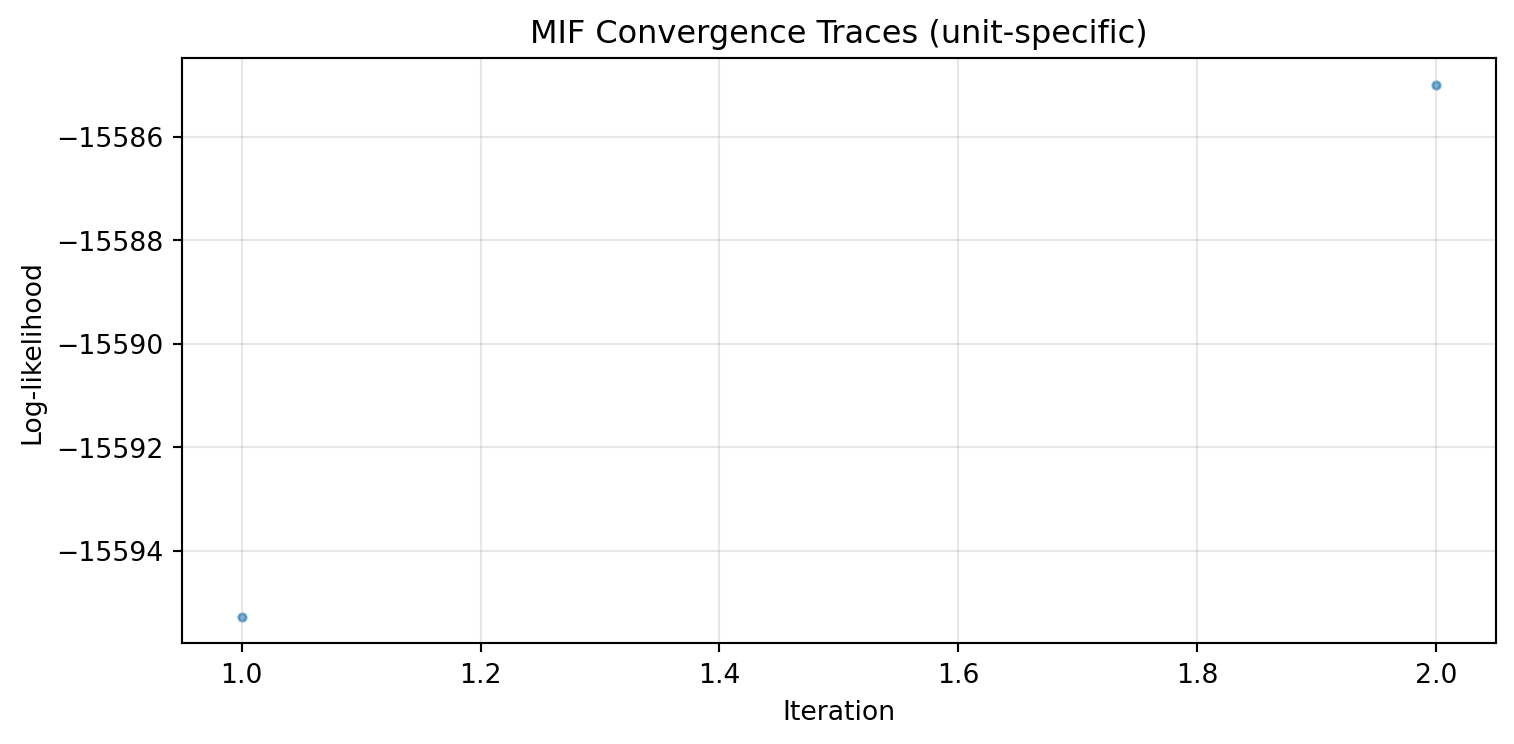

In [19]:
#| warning: false
trace_entries = []
for i, run in enumerate(mif_specific_runs):
    # traces stored on panel results_history[0] if available
    panel = run.get("panel")
    if panel is None or not panel.results_history:
        continue
    mif_res = panel.results_history[0]
    traces = getattr(mif_res, "shared_traces", None)
    if traces is None:
        continue
    loglik_trace = np.asarray(traces)[:, :, 0]  # shape (n_reps, n_iters)
    if loglik_trace.ndim == 3:
        loglik_trace = loglik_trace.mean(axis=0)
    elif loglik_trace.ndim == 2:
        loglik_trace = loglik_trace.mean(axis=0)
    trace_entries.append(
        pd.DataFrame(
            {
                "iteration": np.arange(loglik_trace.shape[-1]),
                "loglik": np.asarray(loglik_trace).flatten(),
                "mif": i + 1,
            }
        )
    )

if trace_entries:
    mifLikes = pd.concat(trace_entries, ignore_index=True)
    mifLikes = mifLikes.replace([np.inf, -np.inf], np.nan).dropna(subset=["loglik"])

    plt.figure(figsize=(8, 4))
    for mif_id, sub in mifLikes.groupby("mif"):
        plt.scatter(sub["iteration"], sub["loglik"], s=8, alpha=0.6, label=f"run {mif_id}")
    plt.xlabel("Iteration")
    plt.ylabel("Log-likelihood")
plt.title("MIF Convergence Traces (unit-specific)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

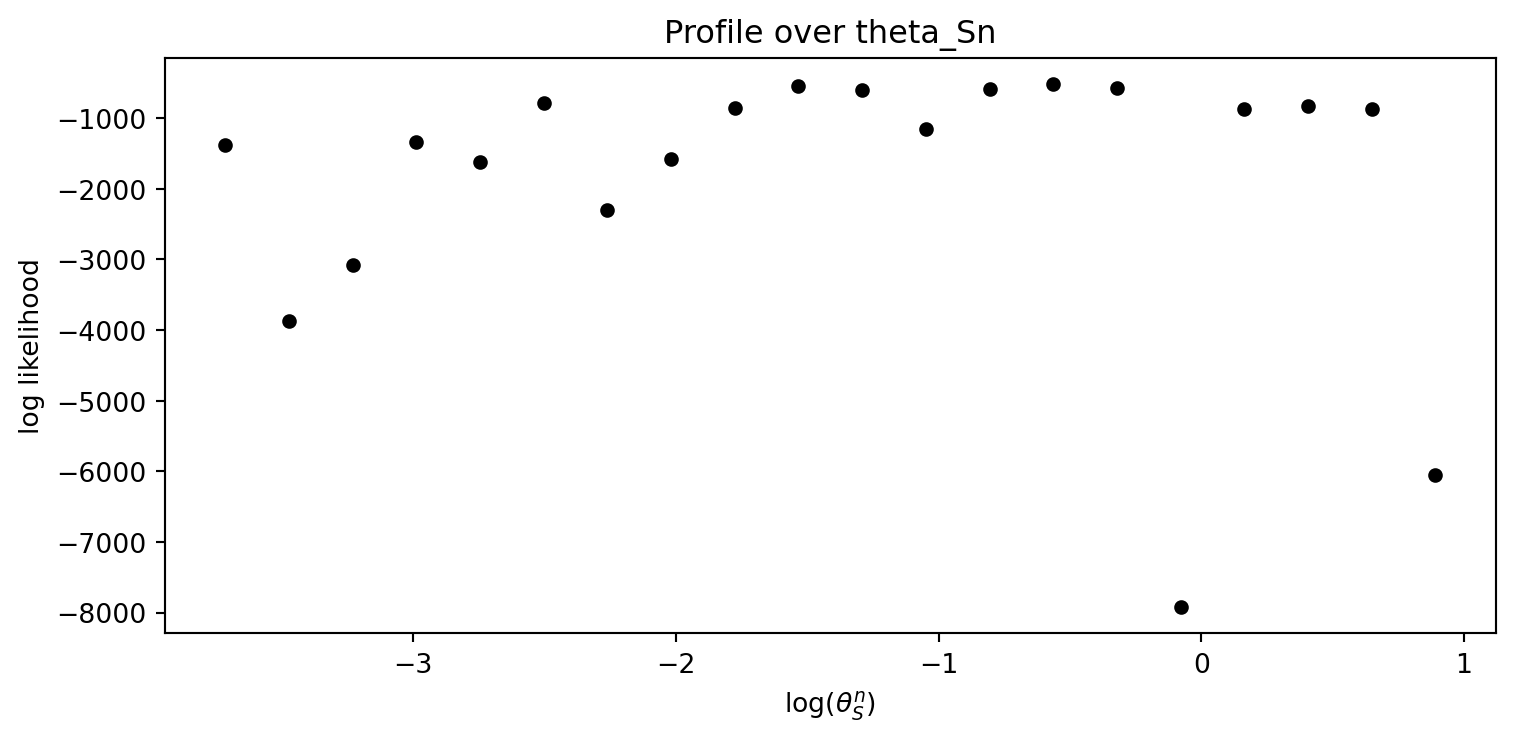

In [20]:
#| label: srjf-profile-thetaSn
#| warning: false
# Profile setup
DEBUG = True
name_str = "theta_Sn"
# Base shared parameter guess (fixed sigSn=0 as above)
shared_parameter_profile = pd.Series(
    {
        "sigF": 1.116997e-05,
        "sigSn": 0.0,
        "f_Sn": 3.116171e-04,
        "rn": 3.369070e02,
        "k_Sn": 6.257932e01,
        "sigJn": 3.073612e-01,
        "theta_Sn": 2.436524e-01,
        "theta_Jn": 3.093602e-03,
    }
)

def generate_parameter_profile(prof_name: str, nprof: int = 20) -> list[pd.Series]:
    shared_ub = shared_parameter_profile * 10
    shared_lb = shared_ub / 100
    ub_unit = np.log(shared_ub[prof_name])
    lb_unit = np.log(shared_lb[prof_name])
    grid_vals = np.linspace(lb_unit, ub_unit, nprof)

    profiles = []
    for val in grid_vals:
        params = shared_parameter_profile.copy()
        params[prof_name] = np.exp(val)
        params["sigSn"] = 0.0
        profiles.append(params)
    return profiles

def generate_sd(x: float, profile_name: str) -> dict[str, float]:
    sd_list = {
        "sigF": x,
        "sigSn": 0.0,
        "f_Sn": x,
        "rn": x,
        "k_Sn": x,
        "sigJn": x,
        "theta_Sn": x,
        "theta_Jn": x,
    }
    sd_list[profile_name] = 0.0
    return sd_list

parameter_shared_list = generate_parameter_profile(name_str, nprof=20)
dent_rw_sd_first = generate_sd(x=0.05, profile_name=name_str)

# Select backend settings
backend_key = "gpu" if use_gpu else "cpu"
idx = run_level - 1
params_sel = algorithmic_params[backend_key]
Np = params_sel["Np"][idx]
Np_rep = params_sel["Np_rep"][idx]
Mp = params_sel["Mp"][idx]
Nmif = params_sel["Nmif"][idx]

def _profile_run(theta_series: pd.Series, seed: int):
    panel = pp.PanelPomp(
        Pomp_dict=pomp_units,
        theta={
            "shared": theta_series.to_frame(name="shared"),
            "unit_specific": unit_empty,
        },
    )
    key = jax.random.key(seed)
    panel.mif(
        J=Mp,
        M=Nmif,
        rw_sd=pp.RWSigma(sigmas=dent_rw_sd_first),
        a=0.7,
        key=key,
    )
    key_pf = jax.random.key(7000 + seed)
    panel.pfilter(J=Np, reps=Np_rep, key=key_pf)
    pf_res = panel.results_history[-1]
    ll_array = pf_res.logLiks.values
    ll_shared = np.apply_along_axis(pp.logmeanexp, -1, ll_array.sum(axis=1))
    ll_shared_se = np.apply_along_axis(pp.logmeanexp_se, -1, ll_array.sum(axis=1))
    if DEBUG:
        return {"mif": panel, "ll": (float(ll_shared.squeeze()), float(ll_shared_se.squeeze()))}
    else:
        return {"mif_coef": panel.results_history[0].theta, "ll": (float(ll_shared.squeeze()), float(ll_shared_se.squeeze()))}

profile_runs = []
for i, theta_series in enumerate(parameter_shared_list):
    profile_runs.append(_profile_run(theta_series, seed=8000 + i))

lls = np.array([r["ll"][0] for r in profile_runs])
ses = np.array([r["ll"][1] for r in profile_runs])
best = int(np.nanargmax(lls))
mif_estimate = profile_runs[best]["mif"].results_history[0].theta if DEBUG else profile_runs[best]["mif_coef"]
pf_loglik_of_mif_estimate = lls[best]
se_pf_loglik = ses[best]

trace_entries = []
for i, run in enumerate(profile_runs):
    panel = run.get("mif") if DEBUG else None
    if panel is None or not panel.results_history:
        continue
    mif_res = panel.results_history[0]
    traces = getattr(mif_res, "shared_traces", None)
    if traces is None:
        continue
    loglik_trace = np.asarray(traces)[:, :, 0]
    if loglik_trace.ndim == 3:
        loglik_trace = loglik_trace.mean(axis=0)
    elif loglik_trace.ndim == 2:
        loglik_trace = loglik_trace.mean(axis=0)
    trace_entries.append(
        pd.DataFrame(
            {
                "iteration": np.arange(loglik_trace.shape[-1]),
                "loglik": np.asarray(loglik_trace).flatten(),
                "mif": i + 1,
                name_str: np.log(theta_series[name_str]),
            }
        )
    )

# Plot profile points (log theta_Sn vs loglik)
theta_vals = np.log([s[name_str] for s in parameter_shared_list])
plt.figure(figsize=(8, 4))
plt.scatter(theta_vals, lls, color="black", s=20)
plt.xlabel(r"$\log(\theta^n_{S})$")
plt.ylabel("log likelihood")
plt.title("Profile over theta_Sn")
plt.tight_layout()
plt.show()

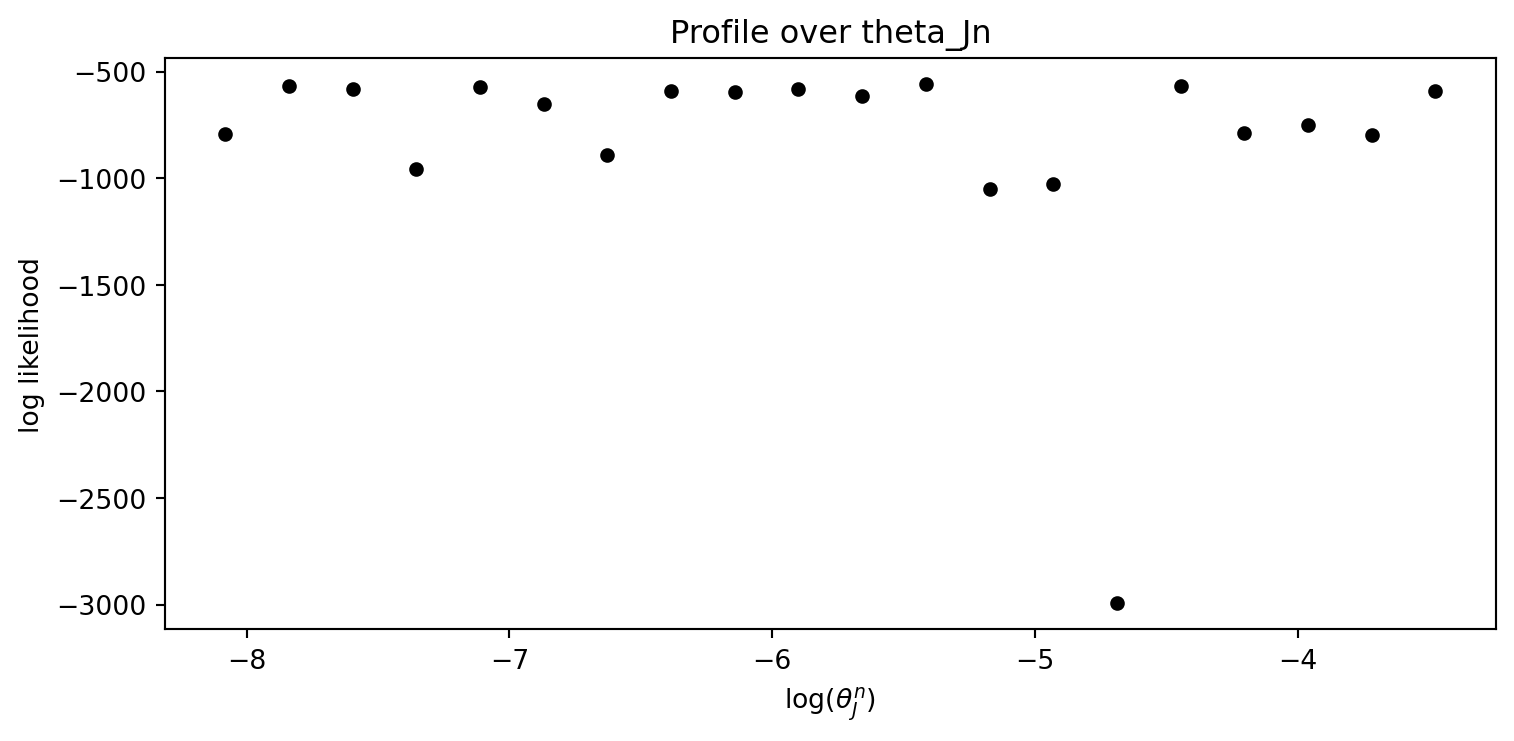

In [21]:
#| label: srjf-profile-thetaJn
#| warning: false
DEBUG = True
name_str = "theta_Jn"
shared_parameter_profile = pd.Series(
    {
        "sigF": 1.116997e-05,
        "sigSn": 0.0,
        "f_Sn": 3.116171e-04,
        "rn": 3.369070e02,
        "k_Sn": 6.257932e01,
        "sigJn": 3.073612e-01,
        "theta_Sn": 2.436524e-01,
        "theta_Jn": 3.093602e-03,
    }
)

parameter_shared_list = generate_parameter_profile(name_str, nprof=20)
dent_rw_sd_first = generate_sd(x=0.05, profile_name=name_str)

backend_key = "gpu" if use_gpu else "cpu"
idx = run_level - 1
params_sel = algorithmic_params[backend_key]
Np = params_sel["Np"][idx]
Np_rep = params_sel["Np_rep"][idx]
Mp = params_sel["Mp"][idx]
Nmif = params_sel["Nmif"][idx]


def _profile_run_theta_jn(theta_series: pd.Series, seed: int):
    panel = pp.PanelPomp(
        Pomp_dict=pomp_units,
        theta={
            "shared": theta_series.to_frame(name="shared"),
            "unit_specific": unit_empty,
        },
    )
    key = jax.random.key(seed)
    panel.mif(
        J=Mp,
        M=Nmif,
        rw_sd=pp.RWSigma(sigmas=dent_rw_sd_first),
        a=0.7,
        key=key,
    )
    key_pf = jax.random.key(9000 + seed)
    panel.pfilter(
        J=Np,
        reps=Np_rep,
        key=key_pf,
    )
    pf_res = panel.results_history[-1]
    ll_array = pf_res.logLiks.values
    ll_shared = np.apply_along_axis(pp.logmeanexp, -1, ll_array.sum(axis=1))
    ll_shared_se = np.apply_along_axis(pp.logmeanexp_se, -1, ll_array.sum(axis=1))
    if DEBUG:
        return {
            "panel": panel,
            "logLik": float(ll_shared.squeeze()),
            "logLik_se": float(ll_shared_se.squeeze()),
        }
    else:
        return {
            "logLik": float(ll_shared.squeeze()),
            "logLik_se": float(ll_shared_se.squeeze()),
        }


profile_runs_jn = [
    _profile_run_theta_jn(theta_series, seed=9000 + i)
    for i, theta_series in enumerate(parameter_shared_list)
]

lls = np.array([r["logLik"] for r in profile_runs_jn])
ses = np.array([r["logLik_se"] for r in profile_runs_jn])
best = int(np.nanargmax(lls))
pf_loglik_of_mif_estimate = lls[best]
se_pf_loglik = ses[best]

theta_vals = np.log([s[name_str] for s in parameter_shared_list])

plt.figure(figsize=(8, 4))
plt.scatter(theta_vals, lls, color="black", s=20)
plt.xlabel(r"$\log(\theta^n_{J})$")
plt.ylabel("log likelihood")
plt.title("Profile over theta_Jn")
plt.tight_layout()
plt.show()

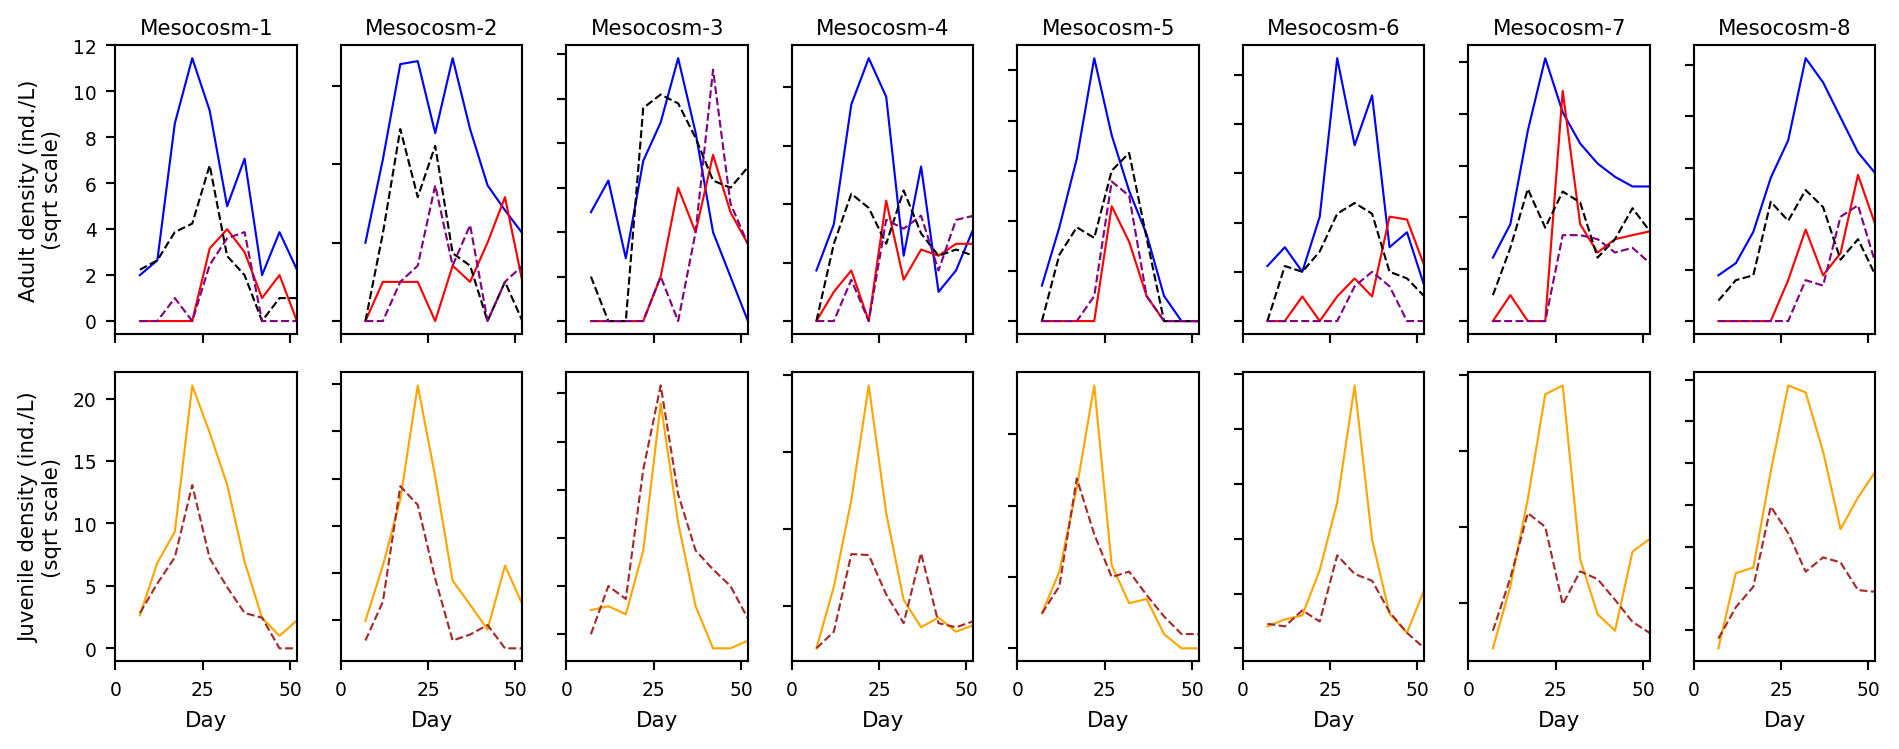

In [22]:
#| label: fig-sirjpf-data
#| fig-cap: 'Observed population densities for *D. dentifera* and *D. lumholtzi* across 8 replicate mesocosms with parasite exposure. Top panel: adult susceptible (blue solid = *D. dentifera*, black dashed = *D. lumholtzi*) and infected (red solid = *D. dentifera*, purple dashed = *D. lumholtzi*) densities. Bottom panel: juvenile densities (orange solid = *D. dentifera*, brown dashed = *D. lumholtzi*). Square-root transformation applied to y-axes for visual clarity. Dynamics exhibit competitive dominance of the native species, variable infection prevalence, and synchronized population crashes characteristic of resource-mediated competition coupled with parasite transmission.'
#| code-fold: true
#| code-summary: Show data processing and plotting code
#| echo: true
#| warning: false
#| out-width: 100%
data_path = Path("data/Mesocosmdata.xls")
if not data_path.exists():
    data_path = Path("../data/Mesocosmdata.xls")

Mesocosm_data = pd.read_excel(data_path, sheet_name=2)

mixed_para = Mesocosm_data.iloc[90:170, :]  # rows 91:170 in 1-based indexing
mixed_para = mixed_para.loc[
    :,
    [
        "rep",
        "day",
        "dent.adult",
        "dent.inf",
        "lum.adult",
        "lum.adult.inf",
        "dent.juv",
        "lum.juv",
    ],
]
mixed_para = mixed_para.iloc[::-1].reset_index(drop=True)
mixed_para["day"] = (mixed_para["day"] - 1) * 5 + 7

trails = ["K", "L", "M", "N", "O", "P", "Q", "S"]
units = [f"Mesocosm {i}" for i in range(1, 9)]

combined = pd.concat(
    [
        mixed_para[mixed_para["rep"] == tr].assign(Mesocosm=units[i])
        for i, tr in enumerate(trails)
    ],
    ignore_index=True,
)
combined["Mesocosm"] = pd.Categorical(combined["Mesocosm"], categories=units, ordered=True)

fig, axes = plt.subplots(2, 8, figsize=(10, 4), sharex=True, sharey=False)

for idx, meso in enumerate(units):
    df = combined[combined["Mesocosm"] == meso]
    # Adults
    axes[0, idx].plot(df["day"], np.sqrt(df["dent.adult"]), color="blue", lw=0.8, linestyle="-")
    axes[0, idx].plot(df["day"], np.sqrt(df["dent.inf"]), color="red", lw=0.8, linestyle="-")
    axes[0, idx].plot(df["day"], np.sqrt(df["lum.adult"]), color="black", lw=0.8, linestyle="--")
    axes[0, idx].plot(df["day"], np.sqrt(df["lum.adult.inf"]), color="purple", lw=0.8, linestyle="--")
    axes[0, idx].set_title(meso.replace(" ", "-"), fontsize=8, pad=4)
    axes[0, idx].set_xlim(0, 52)
    axes[0, idx].set_xticks([0, 25, 50])
    axes[0, idx].tick_params(labelbottom=False, labelsize=7)
    if idx == 0:
        axes[0, idx].set_ylabel("Adult density (ind./L)\n(sqrt scale)", fontsize=8)
    else:
        axes[0, idx].set_yticklabels([])

    # Juveniles
    axes[1, idx].plot(df["day"], np.sqrt(df["dent.juv"]), color="orange", lw=0.8, linestyle="-")
    axes[1, idx].plot(df["day"], np.sqrt(df["lum.juv"]), color="brown", lw=0.8, linestyle="--")
    axes[1, idx].set_xlim(0, 52)
    axes[1, idx].set_xticks([0, 25, 50])
    axes[1, idx].tick_params(labelsize=7)
    if idx == 0:
        axes[1, idx].set_ylabel("Juvenile density (ind./L)\n(sqrt scale)", fontsize=8)
    else:
        axes[1, idx].set_yticklabels([])
    axes[1, idx].set_xlabel("Day", fontsize=8)

plt.tight_layout()
plt.show()